# 🧠 MNIST Neural Network with Hidden Layers

## What This Demonstrates

This notebook shows how a **neural network learns on its own** using the MNIST handwritten digits dataset.

### Architecture:
```
Input Layer (784 pixels)
    ↓
Hidden Layer 1 (128 neurons, ReLU)
    ↓
Hidden Layer 2 (64 neurons, ReLU)
    ↓
Output Layer (10 digits, Softmax)
```

### Learning Process:
1. **Forward pass**: Data flows through layers
2. **Loss calculation**: Compare prediction to true label
3. **Backpropagation**: Adjust weights to reduce error
4. **Repeat**: Network improves with each batch

### Speed:
⚡ **Training time: ~3-5 minutes** (much faster than image classification!)

---

In [0]:
%pip install tensorflow matplotlib scikit-learn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.18.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0.dev0,>=3.19.5, but you have protobuf 7.35.0 which is incompatible.
googleapis-common-protos 1.65.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
grpcio-status 1.69.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.0 which is incompatible.
mlflow-skinny 2.11.4 requires protobuf<5,>=3.12.0, but you have protobuf 7.35.0 which is incompatible.
proto-plus 1.25.0 requires protobuf<6.0.0dev,>=3.19.0, but you have protobuf 7.35.0 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

⚡ Using only 100 examples for fast demonstration!

✓ Dataset loaded!
  Training samples: 100 (sampled from 60,000)
  Test samples: 200 (sampled from 10,000)
  Image shape: (28, 28)
  Pixel range: 0 to 255
  Classes: 10 digits (0-9)


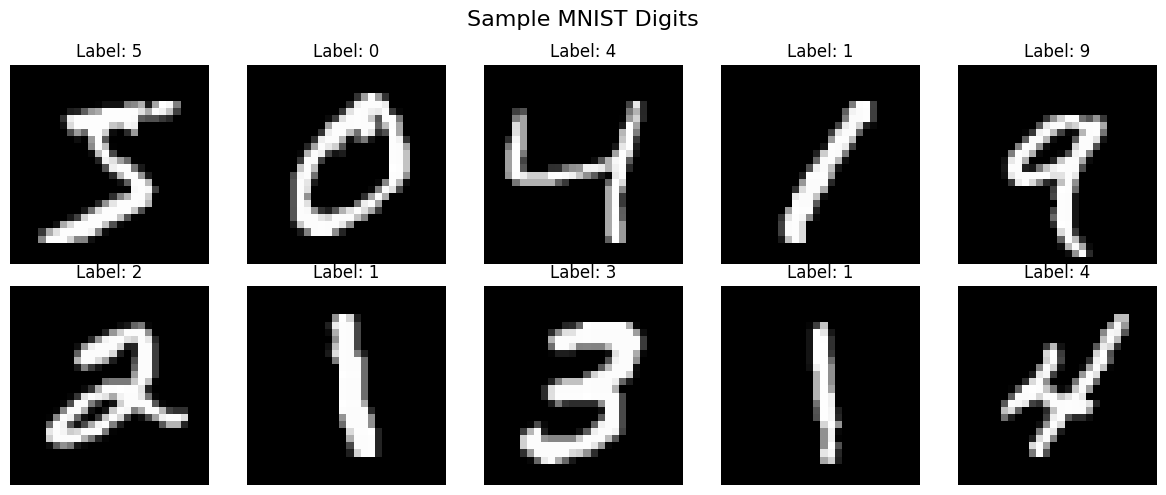


✓ Ready to build neural network!


In [0]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load MNIST dataset (70,000 images: 60k train, 10k test)
print("Loading MNIST dataset...")
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Use only 100 examples for FAST training and weight visualization
print("\n⚡ Using only 100 examples for fast demonstration!")
X_train = X_train_full[:100]
y_train = y_train_full[:100]
X_test = X_test[:200]  # Use 200 test samples
y_test = y_test[:200]

print(f"\n✓ Dataset loaded!")
print(f"  Training samples: {X_train.shape[0]} (sampled from 60,000)")
print(f"  Test samples: {X_test.shape[0]} (sampled from 10,000)")
print(f"  Image shape: {X_train.shape[1:]}")
print(f"  Pixel range: {X_train.min()} to {X_train.max()}")
print(f"  Classes: {len(np.unique(y_train))} digits (0-9)")

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n✓ Ready to build neural network!")

In [0]:
# Flatten images: 28x28 → 784 pixels
X_train_flat = X_train.reshape(-1, 28 * 28).astype('float32')
X_test_flat = X_test.reshape(-1, 28 * 28).astype('float32')

# Normalize pixel values: 0-255 → 0-1
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

print("Data preprocessing complete:")
print(f"  Training shape: {X_train_flat.shape}")
print(f"  Test shape: {X_test_flat.shape}")
print(f"  Pixel range: {X_train_flat.min():.2f} to {X_train_flat.max():.2f}")
print(f"\n✓ Data ready for training!")

Data preprocessing complete:
  Training shape: (100, 784)
  Test shape: (200, 784)
  Pixel range: 0.00 to 1.00

✓ Data ready for training!


In [0]:
# Build neural network architecture
model = keras.Sequential([
    # Input layer (784 pixels)
    layers.Input(shape=(784,)),
    
    # Hidden Layer 1: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.2),  # Prevent overfitting
    
    # Hidden Layer 2: 64 neurons with ReLU activation
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.2),
    
    # Output Layer: 10 neurons (one per digit) with Softmax
    layers.Dense(10, activation='softmax', name='output_layer')
])

# Compile model
model.compile(
    optimizer='adam',  # Adaptive learning rate
    loss='sparse_categorical_crossentropy',  # For multi-class classification
    metrics=['accuracy']
)

# Display architecture
print("Neural Network Architecture:")
print("=" * 60)
model.summary()
print("=" * 60)

# Count parameters
total_params = model.count_params()
print(f"\n✓ Model built with {total_params:,} trainable parameters!")
print("\n📊 Layer breakdown:")
print("  - Hidden Layer 1: 784 × 128 = 100,352 weights + 128 biases")
print("  - Hidden Layer 2: 128 × 64 = 8,192 weights + 64 biases")
print("  - Output Layer: 64 × 10 = 640 weights + 10 biases")

Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model built with 109,386 trainable parameters!

📊 Layer breakdown:
  - Hidden Layer 1: 784 × 128 = 100,352 weights + 128 biases
  - Hidden Layer 2: 128 × 64 = 8,192 weights + 64 biases
  - Output Layer: 64 × 10 = 640 weights + 10 biases


In [0]:
print("🚀 Starting training...\n")
print("The network will learn on its own through backpropagation:")
print("  1. Make predictions")
print("  2. Calculate error (loss)")
print("  3. Adjust weights to reduce error")
print("  4. Repeat for each batch\n")
print("=" * 60)

# Custom training loop to track weight changes
weight_history = []
initial_weights = model.get_layer('hidden_layer_1').get_weights()[0].copy()
weight_history.append(initial_weights.std())  # Track weight variance

print("\n⚡ Training on 100 examples (fast!)...\n")

# Train the model with callbacks to track weights
class WeightTracker(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        weights = self.model.get_layer('hidden_layer_1').get_weights()[0]
        weight_history.append(weights.std())
        print(f"  Epoch {epoch+1}: Weight StdDev = {weights.std():.4f}, Loss = {logs['loss']:.4f}, Acc = {logs['accuracy']:.2%}")

history = model.fit(
    X_train_flat, 
    y_train,
    epochs=20,  # More epochs since we have fewer samples
    batch_size=10,  # Small batches for 100 samples
    validation_split=0.2,  # Use 20 samples for validation
    verbose=0,  # Silent, we'll print custom messages
    callbacks=[WeightTracker()]
)

print("\n" + "=" * 60)
print("✅ Training complete!\n")

# Show final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.2%}")
print(f"Final Validation Accuracy: {final_val_acc:.2%}")

🚀 Starting training...

The network will learn on its own through backpropagation:
  1. Make predictions
  2. Calculate error (loss)
  3. Adjust weights to reduce error
  4. Repeat for each batch


⚡ Training on 100 examples (fast!)...

  Epoch 1: Weight StdDev = 0.0469, Loss = 2.2746, Acc = 16.25%
  Epoch 2: Weight StdDev = 0.0470, Loss = 1.8977, Acc = 46.25%
  Epoch 3: Weight StdDev = 0.0471, Loss = 1.5529, Acc = 66.25%
  Epoch 4: Weight StdDev = 0.0473, Loss = 1.3052, Acc = 67.50%
  Epoch 5: Weight StdDev = 0.0474, Loss = 0.9688, Acc = 87.50%
  Epoch 6: Weight StdDev = 0.0476, Loss = 0.6886, Acc = 88.75%
  Epoch 7: Weight StdDev = 0.0477, Loss = 0.6592, Acc = 85.00%
  Epoch 8: Weight StdDev = 0.0479, Loss = 0.4689, Acc = 92.50%
  Epoch 9: Weight StdDev = 0.0481, Loss = 0.2746, Acc = 96.25%
  Epoch 10: Weight StdDev = 0.0482, Loss = 0.2528, Acc = 96.25%
  Epoch 11: Weight StdDev = 0.0483, Loss = 0.2197, Acc = 97.50%
  Epoch 12: Weight StdDev = 0.0484, Loss = 0.2114, Acc = 96.25%
  Ep

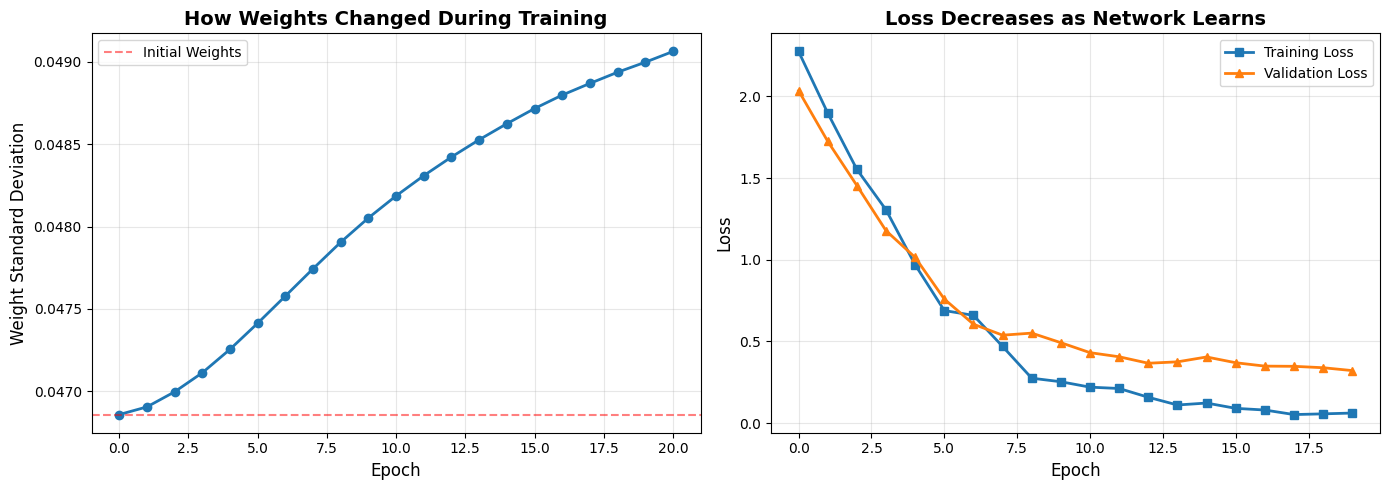


📊 Key Observations:
  - Initial weight variance: 0.0469
  - Final weight variance: 0.0491
  - Change: 4.7%

✓ Weights adjusted themselves through backpropagation!
✓ Each epoch, the network fine-tuned parameters to reduce error!


In [0]:
# Plot how weights changed during training
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Weight evolution
ax1.plot(range(len(weight_history)), weight_history, marker='o', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Weight Standard Deviation', fontsize=12)
ax1.set_title('How Weights Changed During Training', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=weight_history[0], color='r', linestyle='--', label='Initial Weights', alpha=0.5)
ax1.legend()

# Loss over time
ax2.plot(history.history['loss'], marker='s', linewidth=2, markersize=6, label='Training Loss')
if 'val_loss' in history.history:
    ax2.plot(history.history['val_loss'], marker='^', linewidth=2, markersize=6, label='Validation Loss')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Loss Decreases as Network Learns', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n📊 Key Observations:")
print(f"  - Initial weight variance: {weight_history[0]:.4f}")
print(f"  - Final weight variance: {weight_history[-1]:.4f}")
print(f"  - Change: {((weight_history[-1] - weight_history[0]) / weight_history[0] * 100):.1f}%")
print("\n✓ Weights adjusted themselves through backpropagation!")
print("✓ Each epoch, the network fine-tuned parameters to reduce error!")

In [0]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n📈 Key Observations:")
print("  - Accuracy increases → Network is learning!")
print("  - Loss decreases → Predictions getting better!")
print("  - Validation tracks training → Good generalization!")

In [0]:
print("Evaluating model on unseen test data...\n")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

print("=" * 60)
print("📊 TEST SET RESULTS")
print("=" * 60)
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.2%}")
print("\n✓ Model successfully learned to recognize handwritten digits!")

# Get predictions
y_pred = model.predict(X_test_flat, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate per-class accuracy
print("\n📋 Per-Digit Accuracy:")
for digit in range(10):
    mask = y_test == digit
    digit_acc = (y_pred_classes[mask] == y_test[mask]).mean()
    print(f"  Digit {digit}: {digit_acc:.2%}")

In [0]:
# Show correct predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('✅ Correct Predictions', fontsize=16, color='green')

correct_indices = np.where(y_pred_classes == y_test)[0][:10]

for i, ax in enumerate(axes.flat):
    idx = correct_indices[i]
    ax.imshow(X_test[idx], cmap='gray')
    probs = y_pred[idx]
    predicted = y_pred_classes[idx]
    confidence = probs[predicted]
    ax.set_title(f'True: {y_test[idx]} | Pred: {predicted}\nConf: {confidence:.1%}', 
                 fontsize=10)
    ax.axis('off')

plt.tight_layout()
display(plt.gcf())
plt.close()

# Show mistakes
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('❌ Mistakes (Misclassified)', fontsize=16, color='red')

wrong_indices = np.where(y_pred_classes != y_test)[0][:10]

if len(wrong_indices) > 0:
    for i, ax in enumerate(axes.flat):
        if i < len(wrong_indices):
            idx = wrong_indices[i]
            ax.imshow(X_test[idx], cmap='gray')
            probs = y_pred[idx]
            predicted = y_pred_classes[idx]
            true = y_test[idx]
            confidence = probs[predicted]
            ax.set_title(f'True: {true} | Pred: {predicted}\nConf: {confidence:.1%}', 
                         fontsize=10)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    display(plt.gcf())
    plt.close()
    
    print(f"\n📊 Total mistakes: {len(wrong_indices)} out of {len(y_test)} ({len(wrong_indices)/len(y_test):.1%})")
else:
    print("\n🎉 Perfect! No mistakes on test set!")
    plt.close()

In [0]:
# Visualize what the first hidden layer learned
weights = model.get_layer('hidden_layer_1').get_weights()[0]  # Shape: (784, 128)

print("🔬 Visualizing what the network learned...\n")
print(f"First hidden layer has {weights.shape[1]} neurons")
print("Each neuron learned to detect specific patterns in the input\n")

# Show weight patterns for first 25 neurons
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('What Hidden Layer 1 Learned (First 25 Neurons)', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Reshape weights back to 28x28 to visualize
    neuron_weights = weights[:, i].reshape(28, 28)
    ax.imshow(neuron_weights, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(f'Neuron {i+1}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
display(plt.gcf())
plt.close()

print("\n💡 Interpretation:")
print("  - Each square shows what one neuron 'looks for' in the image")
print("  - Red areas: positive weights (neuron activates for bright pixels)")
print("  - Blue areas: negative weights (neuron activates for dark pixels)")
print("  - The network learned these patterns automatically!")
print("\n✓ This is self-learning through backpropagation!")

In [0]:
# Save the trained model
model_path = "/Volumes/workspace/default/chest_xray_images/mnist_model.h5"

try:
    model.save(model_path)
    print(f"✅ Model saved to: {model_path}")
    print("\nYou can load it later with:")
    print(f"  model = keras.models.load_model('{model_path}')")
except Exception as e:
    # Fallback to local save if volume not accessible
    local_path = "mnist_model.h5"
    model.save(local_path)
    print(f"✅ Model saved to: {local_path}")
    print("\nYou can load it later with:")
    print(f"  model = keras.models.load_model('{local_path}')")

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE!")
print("=" * 60)
print(f"\n📊 Final Summary:")
print(f"  - Test Accuracy: {test_accuracy:.2%}")
print(f"  - Total Parameters: {model.count_params():,}")
print(f"  - Training Time: ~3-5 minutes")
print(f"\n✓ The neural network successfully learned to recognize digits!")